# Linear Regression using PyTorch
We have explored **Linear Regression** using python libraries like numpy, pandas and sklearn to produce a model. However the same method can't perform as well when the size of the dataset is very large. 

Pytorch supports [*Tensors*](https://docs.pytorch.org/docs/2.12/tensors.html) which are a unique data structure that can be processed using a GPU or other hardware accelerators. Therefore, if we want to process large datasets.

## Importing PyTorch and other dependencies
Importing PyTorch for tensors and autograd which is extremely important for machine learning. Matplot library is used for data visualization, especially to compare between trained and untrained models.

In [199]:
# Import PyTorch and matplotlib
import torch
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.12.0+cu126'

## Setting up agnostic code
**Agnostic Code** is a code that runs independently of the environment. This means it works regardless of the hardware of the computer. We can use agnostic device code so that it chooses the most efficient and compatible
hardware based on the device

In [200]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## Data Preparation

First step is to load the dataset which can be done like usual with pandas library.

In [201]:
import pandas as pd
import torch

df = pd.read_csv(r'./Resources/linear-regression-data1.csv')
df.head(6) #loads first six data 

,x,y
0,0.00,0.300
1,0.02,0.314
2,0.04,0.328
3,0.06,0.342
4,0.08,0.356
5,0.10,0.370


## Conversion to Tensors
Since PyTorch uses Tensors and more efficient to use, we need to convert the loaded dataset into tensors

In [202]:
# convert to torch tensors for use in the notebook
X = torch.tensor(df['x'].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['y'].values, dtype=torch.float32).unsqueeze(1)
print(X.shape)
print(y.shape)

torch.Size([50, 1])
torch.Size([50, 1])


## Splitting the dataset
We split the dataset into two parts with the ratio of 80% to 20%. We do this so that we can train the model using the 80% of the data and we check if the prediction from the model is correct using the 20% of the data. Uncreatively named, **training data** is the data we use to train the model and the data used to test the model is called **testing data**.

In [203]:
# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

## Visualization of data
The training data and testing data is visualized as follows.

In [204]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

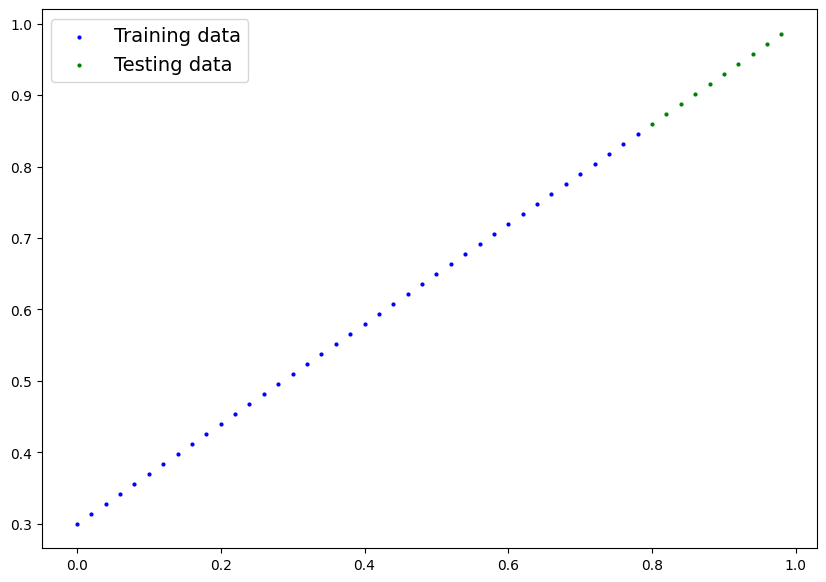

In [205]:
# Note: If you've reset your runtime, this function won't work, 
# you'll have to rerun the cell above where it's instantiated.
plot_predictions(X_train, y_train, X_test, y_test)

## ALgorithm Selection
Since we are doing Linear Regression, we are going to make a Linear equation using parameters.
Linear Regression in PyTorch is not as simple as using linear Regression in sklearn, In sklearn making a model is as simple as 

```
from sklearn.linear_model import LinearRegression
model = LinearRegression()
```

## Model Architecture & Mathematics

As mentioned earlier in `scikit-learn`, building a model is a high-level abstraction (`LinearRegression()`) where the underlying math is hidden. PyTorch is complex in that it requires us to build the model manually.

Our custom `LinearRegressionModel` relies on two fundamental steps:

1. **Initialization (`__init__`):** Where we define our model's parameters (weights and biases).
2. **The Forward Pass (`forward`):** Where we explicitly define the mathematical computation that transforms our input data ($x$) into a prediction ($\hat{y}$).


### Equation for the linear model

The equation for a straight line is represented as

$$y = mx + c$$

Where,
* $m$ is the slope/gradient.
* $c$ is the y-intercept.

For Ml and DL we use the same concept, but we alter the notation slightly. This is so we can match it with standard matrix calculus.

$$\hat{y} = wx + b$$

- $w$ **(Weight):** Its the slope ($m$) from line equation. It dictates the steepness and direction of our line.
- $b$ **(Bias):** Its the y-intercept ($c$) from line equation. It shifts the entire line up or down along the y-axis.
- $x$: Its feature for our model.
- $\hat{y}$: Our **predicted** output (the hat `^` distinguishes the model's prediction from the true label $y$).

## **Implementaion of the model:**

In [206]:
import torch 
from torch import nn
# Create a Linear Regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch is a nn.Module (think of this as neural network lego blocks)
    def __init__(self):
        super().__init__() 
        self.weights = nn.Parameter(torch.randn(1, # <- start with random weights (this will get adjusted as the model learns)
                                                dtype=torch.float), # <- PyTorch loves float32 by default
                                   requires_grad=True) # <- can we update this value with gradient descent?)

        self.bias = nn.Parameter(torch.randn(1, # <- start with random bias (this will get adjusted as the model learns)
                                            dtype=torch.float), # <- PyTorch loves float32 by default
                                requires_grad=True) # <- can we update this value with gradient descent?))

    # Forward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor: # <- "x" is the input data (e.g. training/testing features)
        return self.weights * x + self.bias # <- this is the linear regression formula (y = m*x + b)

### Model Parameters (`nn.Parameter`)

Inside our PyTorch class, we have explicitly wrapped our parameters (weights and biases) using `nn.Parameter()`. This is a specialized tensor wrapper that tells PyTorch two critical things:

- **Tracking for Optimization:** By setting `requires_grad=True`, PyTorch's automatic differentiation engine (Autograd) to keeps a record for every mathematical operation performed on the parameters. This lets the model calculate gradients later during backpropagation.
- **Random Initialization:** We initialize with `torch.randn(1, dtype=torch.float)`, creating a single random float32 value. This means our model's parameters start with completely random guesses for its weight ($w$) and bias ($b$) and as the model learns it finds optimum values for parameters with least cost function and convergence.


### The Impact of parameters on the Model

Parameters dictate the shape of the line; therefore, our model itself. The parameters are adjusted as the model learns.

- **Weight ($w$):** The line pivots or rotates. A higher $w$ makes the line steeper; a negative $w$ slants the line downwards.
- **Bias ($b$):** The line shifts cleanly up or down without rotating. This ensures that even if our input $x$ is zero, the model can still predict a non-zero baseline value.

In [207]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [208]:
print(model_0.weights.dtype)
print(model_0.bias.dtype)

torch.float32
torch.float32


In [209]:
# Make predictions with model
with torch.inference_mode(): 
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

y_preds[:5]

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251]])

In [210]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}") 
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


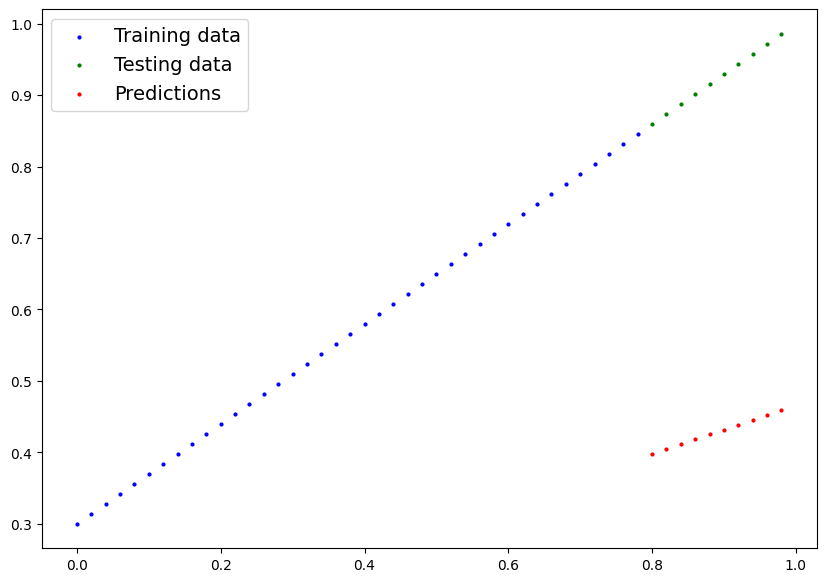

In [211]:
plot_predictions(predictions=y_preds)

## Loss Function Selection

In [212]:
# Loss Function Selection
from torch import nn # nn contains all of PyTorch's building blocks for neural networks

# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(
                    params=model_0.parameters(), # parameters of target model to optimize
                    lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

In [213]:
torch.manual_seed(42)

# Set the number of epochs (how many times the model will pass over the training data)
epochs = 175

# Create empty loss lists to track values
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    ### Training

    # Put model in training mode (this is the default state of a model)
    model_0.train()

    # 1. Forward pass on train data using the forward() method inside 
    y_pred = model_0(X_train)
    # print(y_pred)

    # 2. Calculate the loss (how different are our models predictions to the ground truth)
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad of the optimizer
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Progress the optimizer
    optimizer.step()

    ### Testing

    # Put the model in evaluation mode
    model_0.eval()

    with torch.inference_mode():
      # 1. Forward pass on test data
      test_pred = model_0(X_test)

      # 2. Caculate loss on test data
      test_loss = loss_fn(test_pred, y_test.type(torch.float)) # predictions come in torch.float datatype, so comparisons need to be done with tensors of the same type

      # Print out what's happening every 10 epochs
      if epoch % 10 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")

Epoch: 0 | MAE Train Loss: 0.31288138031959534 | MAE Test Loss: 0.48106518387794495 
Epoch: 10 | MAE Train Loss: 0.1976713240146637 | MAE Test Loss: 0.3463551998138428 
Epoch: 20 | MAE Train Loss: 0.08908725529909134 | MAE Test Loss: 0.21729660034179688 
Epoch: 30 | MAE Train Loss: 0.053148526698350906 | MAE Test Loss: 0.14464017748832703 
Epoch: 40 | MAE Train Loss: 0.04543796554207802 | MAE Test Loss: 0.11360953003168106 
Epoch: 50 | MAE Train Loss: 0.04167863354086876 | MAE Test Loss: 0.09919948130846024 
Epoch: 60 | MAE Train Loss: 0.03818932920694351 | MAE Test Loss: 0.08886633068323135 
Epoch: 70 | MAE Train Loss: 0.03476089984178543 | MAE Test Loss: 0.0805937647819519 
Epoch: 80 | MAE Train Loss: 0.03132382780313492 | MAE Test Loss: 0.07232122868299484 
Epoch: 90 | MAE Train Loss: 0.02788739837706089 | MAE Test Loss: 0.06473556160926819 
Epoch: 100 | MAE Train Loss: 0.024458957836031914 | MAE Test Loss: 0.05646304413676262 
Epoch: 110 | MAE Train Loss: 0.021020207554101944 | MAE

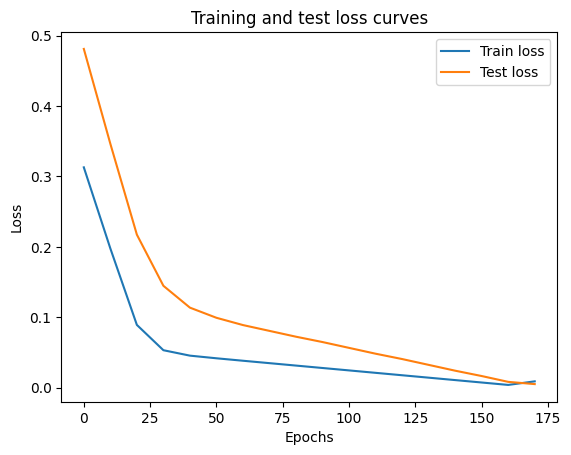

In [214]:
# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [215]:
# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: 0.7, bias: 0.3")

The model learned the following values for weights and bias:
OrderedDict({'weights': tensor([0.6951]), 'bias': tensor([0.2993])})

And the original values for weights and bias are:
weights: 0.7, bias: 0.3


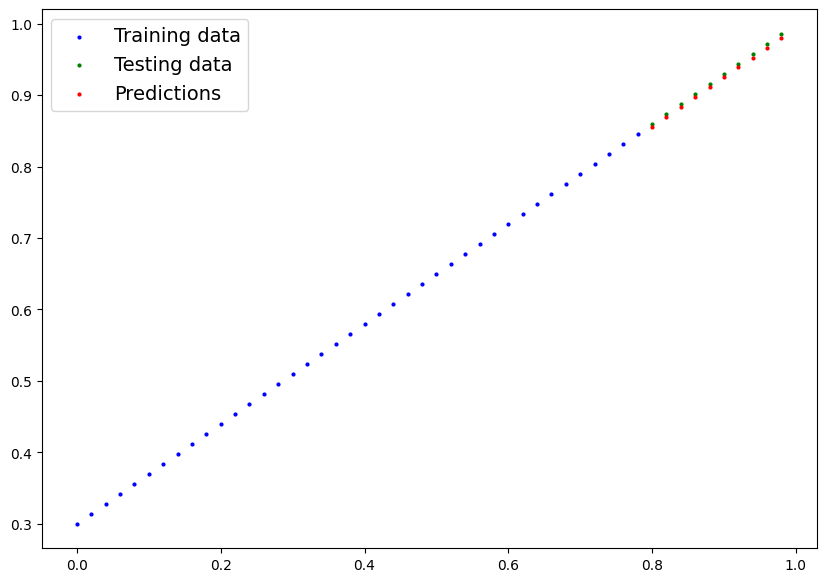

In [216]:
# 1. Set the model in evaluation mode
model_0.eval()

# 2. Setup the inference mode context manager
with torch.inference_mode():
  # 3. Make sure the calculations are done with the model and data on the same device
  # in our case, we haven't setup device-agnostic code yet so our data and model are
  # on the CPU by default.
  # model_0.to(device)
  # X_test = X_test.to(device)
  y_preds = model_0(X_test)
plot_predictions(predictions=y_preds)

# Conclusion

Linear Regression was successfully implemented using PyTorch, leveraging the key data strcuture tensors which are optimized for GPUs rather than traditional CPU-based libraries like Scikit-Learn. However the model architecture and parameters had to created manually. The explicit training loop with Stochastic Gradient Descent (SGD) and **MSE loss** was used. We observed clear convergence and the model predicted the values close to the testing dataset. After a few iterations epoch of 175 was found to produce the best predictions.

## Importance of Linear Regression

Linear Regression is a foundational algorithm in machine learning. It is an entry point for understanding neural network principles (weights, biases, and backpropagation) and offers high interpretability, computational efficiency, and clear baseline performance for predictive modeling.

## Shortcomings of Linear Regression

Despite its efficiency, Linear Regression has notable limitations:

- **Assumption of Linearity:** It cannot capture non-linear relationships between variables, limiting its effectiveness on complex, real-world datasets.
- **Sensitivity to Outliers:** Outliers can drastically skew the learned weights and bias, leading to poor generalization.
- **Multicollinearity:** Linear Regression assumes features are **not highly correlated with each other**. When strong multicollinearity exists, coefficient estimates become unstable and unreliable.